In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

raw_df = pd.read_csv('Data/users_orders(in).csv', engine='pyarrow')

df = raw_df.copy()
df.dtypes

user_id                    object
order_id                   object
order_date                 object
revenue                   float64
is_new_user                  bool
days_since_first_order      int64
lifetime_orders_so_far      int64
device                     object
channel                    object
country                    object
sessions_before_order       int64
flagged_segment              bool
marketing_cost            float64
dtype: object

### Sprawdzam dane pod względem sanity check

In [2]:
# Zmieniam dtype order_date z object na datetime
cleared_df = df['order_date'] = pd.to_datetime(df['order_date'])

# Sprawdzam czy występują duplikaty. Jeżeli tak to jakie one są faktycznie
duplicates = df[df.duplicated(subset=['user_id','order_id'], keep=False)]
duplicates.sort_values(by=['user_id','order_id'])

# Znalazłem 100 duplikatów więc je usuwam
cleared_df = df.drop_duplicates()

# Sprawdzam czy są nulle
cleared_df.isna().sum()	

user_id                   0
order_id                  0
order_date                0
revenue                   0
is_new_user               0
days_since_first_order    0
lifetime_orders_so_far    0
device                    0
channel                   0
country                   0
sessions_before_order     0
flagged_segment           0
marketing_cost            0
dtype: int64

### Zapoznaje się z kolumnami i danymi

In [3]:
'''Zapoznaje się z wartościami w kolumnach i całym datasetem'''

cleared_df.dtypes

# Sprawdzam zakres dat
cleared_df['order_date'].min()
cleared_df['order_date'].max()

# # Sprawdzam wartości jakie występują
cleared_df['is_new_user'].unique()
cleared_df['device'].unique()
cleared_df['channel'].unique()
cleared_df['country'].unique()
cleared_df['flagged_segment'].unique()
cleared_df['marketing_cost'].unique()

array([ 0., 12., 20.,  5.])

### 3. Jakość danych: Czy ufasz tym danym ? Wskaż ewentualne anomalie, które mogą wpływać na wynik analizy

Po oczyszczeniu danych z duplikatów określam dane jako **wystarczające i wartościowe** do przeprowadzenia analizy segmentu True w kontekście tej kampanii.  

Anomalie wykryte wiążą się z flagą `is_new_user`. Istnieją rekordy, które określają nowego usera jako osobę z więcej niż 1 złożonym zamówieniem. Niespójności mogą wynikać z błędów danych lub innej logiki biznesowej – należy to uwzględnić w interpretacji. 

Dodatkowo zauważono niezgodność z flagą `lifetime_orders_so_far`. Nie zgadza się ona inkrementalnie co może powodać na błędnie określoną wcześniej wymienioną kolumnę `is_new_user`. Możliwe także nieprawidłowe określanie ilości złożonych zamówień.

In [4]:
'''Sprawdzam występowanie anomalii'''

# Sprawdzam nieprawidłowe wartości
cleared_df[(cleared_df['revenue'] < 0)]
cleared_df[(cleared_df['days_since_first_order'] < 0)]
cleared_df[(cleared_df['lifetime_orders_so_far'] < 0)]
cleared_df[(cleared_df['sessions_before_order'] <= 0)]
cleared_df[(cleared_df['marketing_cost'] < 0)]

# Sprawdzam nieprawidłowe relacje
cleared_df[(cleared_df['marketing_cost'] > 0) &
           (cleared_df['channel'] == 'organic')
           ]

cleared_df[(cleared_df['marketing_cost'] > 0) &
           (cleared_df['channel'] == 'direct')
           ]

# Sprawdzam outlinery

cleared_df[(cleared_df['days_since_first_order'] > 170)]

# Większość dużych zamówień są z device = mobile, zadna z marketing_price 20.0 (19x)
cleared_df[(cleared_df['revenue'] > 3000)]

# Widzę wysoką ilość zamówień głównie z device = mobile i większość country = PL. (8x)
cleared_df[(cleared_df['lifetime_orders_so_far'] > 30)] 

# Większość dużych ilości sesji pochodzi z mobile i flagged_segment True (12x)
cleared_df[(cleared_df['sessions_before_order'] > 25)] 

# Znalazłem pierwszą anomalie, 230 userów, którzy są określani jako nie nowi użytkownicy ale ich day_since_first_order wynosi 0. Order_date - 05.01.2026 - 16.01.2026. Jakis błąd w ETL ? Migracje ? Inna interpretacja new_user ?
cleared_df[
    (cleared_df['days_since_first_order'] == 0) &
    (cleared_df['is_new_user'] == False)
].sort_values(by='order_date', ascending=True)

# Po ponownym przyjrzeniu sie problemowi określenia nowego użytkownika, odkryłem, że nie jest spójna z trasakcyjnym first order. Istnieje 3729 rekordów z lifetime_orders_so_far > 1 i is_new_user = True. Oznacza to ze is_new_user moze pochodzic z innej logiki biznesowej. Możliwe, że będę musiał ustalić nowy współczynnik nowego usera np.lifetime_orders_so_far == 1.
cleared_df[
    (cleared_df['lifetime_orders_so_far'] > 1) &
    (cleared_df['is_new_user'] == True) 
].sort_values(by='order_date', ascending=True)

cleared_df[(cleared_df['lifetime_orders_so_far'] < 1) &
           (cleared_df['is_new_user'] == False)
           ]

# Sprawdzam jak działa kolumna lifetime_orders_so_far, czy uwzględnia samą siebie do sumy. Jeżeli nie zobacze żadnego wiersza o wartości 0, zakładam, że pierwsze zamówienie po pojawieniu się w bazie danych ma wartość lifetime_orders_so_far = 1
cleared_df[(cleared_df['lifetime_orders_so_far'] == 0)].value_counts()

# Sprawdzam czy flaga lifetime_orders_so_far zgadza się inkrementalnie. Zauważam tutaj problem dla przykładu użytkownik o user_id u_0000004 posiada skok zamówienia z 4 na 10, a powininen mieć 5
incr_test_df = cleared_df.sort_values(['user_id','order_date'])

incr_test_df['prev_orders'] = incr_test_df.groupby('user_id')['lifetime_orders_so_far'].shift(1)

incr_test_df['is_valid_increment'] = (
    (incr_test_df['lifetime_orders_so_far'] == 1)|
    (incr_test_df['lifetime_orders_so_far'] == incr_test_df['prev_orders'] + 1)
    )

invalid_rows = incr_test_df[~incr_test_df['is_valid_increment']]
invalid_rows.shape[0]
incr_test_df['diff'] = incr_test_df.groupby('user_id')['lifetime_orders_so_far'].diff()
incr_test_df['diff'].value_counts(dropna=False)

incr_test_df

# Dodaje kolumne lifetime_orders_fixed jako nową flagę do weryfikowania ilości zamówień i opieram ją na swoich własnych założeniach: Pierwsze pojawienie się w datasecie oznacza pierwsze zamówienie.

cleared_df['lifetime_orders_fixed'] = cleared_df.groupby('user_id').cumcount() + 1

# Sprawdzam czy występują jednocześnie userzy co maja flagę true i false.
flag_counts = cleared_df.groupby('user_id')['flagged_segment'].nunique().reset_index()
users_with_both_flags = flag_counts[flag_counts['flagged_segment'] == 2]['user_id']
len(users_with_both_flags)

/tmp/ipykernel_5103/3904621609.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleared_df['lifetime_orders_fixed'] = cleared_df.groupby('user_id').cumcount() + 1


0

### Wstęp do analizy

Grupa użytkowników określona w kontekście biznesowym odnosi się do kampanii obowiązującej na urządzenia mobilne w Hiszpanii i Polsce.  
`marketing_cost` w tej kampanii wynosił **20 euro**.  

Dla porównania używam segmentu użytkowników z innej kampanii mobilnej w tych samych krajach, gdzie `marketing_cost` wynosił **12 euro**.  

Nie posiadam więcej danych kosztowych więc `marketing_cost` określam jako stałą wartość dla każdego zamówienia (np. zniżka na zamówienie).

In [5]:
'''Określam grupę badawcza, którą będę badać i porównywać (True i False)'''
flagged_true_df = cleared_df[(cleared_df['flagged_segment'] == True)]

flagged_true_df['device'].unique()
flagged_true_df['country'].unique()
flagged_true_df['marketing_cost'].unique()

flagged_false_df = cleared_df[
    (cleared_df['device'] == 'mobile') &
    (cleared_df['country'].isin(['ES', 'PL'])) &
    (cleared_df['channel'] == 'paid') &
    (cleared_df['marketing_cost'] == 12.0)
    
].sort_values(by='order_date', ascending=True)

### 1. Rentowność netto: Czy segment jest faktycznie stratny, gdy weźmiemy pod uwagę marketing_cost? Oblicz Profit (Revenue - Cost).

Nie otrzymałem dodatkowych informacji o innych stałych kosztach takich jak np. prowizja płatności, podatki, koszty operacyjne itp.. więc trzymam sie sugestii zadania:

**profit = revenue − cost**

Przeprowadzona analiza wskazała, że segment oznaczony jako `flagged_segment = True` **nie jest stratny**:

- Łączny profit oflagowanego segmentu: **210 253 euro**  
- Średni profit per order oflagowanego segmentu: **25 euro**  
- Zwrot inwestycji (ROI) jest na poziomie **128%**

In [6]:
'''Licze metryki do zadania pierwszego'''

# Ogólny profit oflagowanego segmentu
total_revenue_true = flagged_true_df['revenue'].sum()
total_marketing_cost_true = flagged_true_df['marketing_cost'].sum()

flagged_true_profit = (total_revenue_true - total_marketing_cost_true).round(2)


# Ogólny średni profit dla oflagowanego segmentu per order
avg_profit_true_per_order = (flagged_true_df['revenue'] - flagged_true_df['marketing_cost']).mean().round(2)


# Zwrot inwestycji dla oflagowanego segmentu
roi_df_per_order_true = ((total_revenue_true - total_marketing_cost_true)/ total_marketing_cost_true * 100).round(2)

#---------------------------------------------------False segement-----------------------------------------

# Ogólny profit oflagowanego segmentu
total_revenue_false = flagged_false_df['revenue'].sum()
total_marketing_cost_false = flagged_false_df['marketing_cost'].sum()

flagged_false_profit = (total_revenue_false - total_marketing_cost_false).round(2)


# Ogólny średni profit dla oflagowanego segmentu
avg_profit_false_per_order = (flagged_false_df['revenue'] - flagged_false_df['marketing_cost']).mean().round(2)

# Zwrot inwestycji dla oflagowanego segmentu
roi_df_per_order_false = ((total_revenue_false - total_marketing_cost_false)/ total_marketing_cost_false * 100).round(2)

print(f'Segment oflagowany jako True')
print(f'Całkowity profit oflagowanego segmentu (True): {flagged_true_profit}')
print(f'Średni profit oflagowanego segmentu per order (True): {avg_profit_true_per_order }')
print(f'Zwrot z inwestycji oflagowanych userów jako true na poziomie (per order) {roi_df_per_order_true}%\n')
print(f'Segment oflagowany jako False')
print(f'Całkowity profit oflagowanego segmentu (False): {flagged_false_profit}')
print(f'Średni profit oflagowanego segmentu per order (False): {avg_profit_false_per_order}')
print(f'Zwrot z inwestycji oflagowanych userów jako true na poziomie (per order) {roi_df_per_order_false}%')

Segment oflagowany jako True
Całkowity profit oflagowanego segmentu (True): 210253.86
Średni profit oflagowanego segmentu per order (True): 25.7
Zwrot z inwestycji oflagowanych userów jako true na poziomie (per order) 128.49%

Segment oflagowany jako False
Całkowity profit oflagowanego segmentu (False): 592539.36
Średni profit oflagowanego segmentu per order (False): 34.58
Zwrot z inwestycji oflagowanych userów jako true na poziomie (per order) 288.19%


### 2. Lojalność vs. Transakcyjność: Czy zachowanie tych użytkowników w czasie (Retention/Lifetime Orders) uzasadnia wyższy koszt ich pozyskania i obsługi (liczba sesji)?

Segment True **nie uzasadnia wyższego kosztu pozyskania**.  

- Typowy użytkownik składa tyle samo zamówień i generuje podobny przychód co segment False  
- Retencja jest minimalnie mniejsza  
- Średnia liczba sesji per order jest wyższa lecz to nie wpływa na marketing cost
- Mediana tygodniowych zamówień jest w obu segmentach zbliżona  

**W efekcie:** Segment True nie generuje dodatkowej wartości rekompensującej wyższy koszt pozyskania.

### Sprawdzam wykresy dla określonych grup a także jak wygląda sprzedaż w czasie

Wykresy oflagowanych grup wskazują na silną skośność prawostronną. Zawiera długi ogon i potencjalne outlinery, które wcześniej określiłem jako mało znaczące. Przeliczę percentyle i sprawdzę rozstęp międzykwartylowy, ponieważ jest odporne na outlinery. Różnica między grupami jest niewielka 

37.875


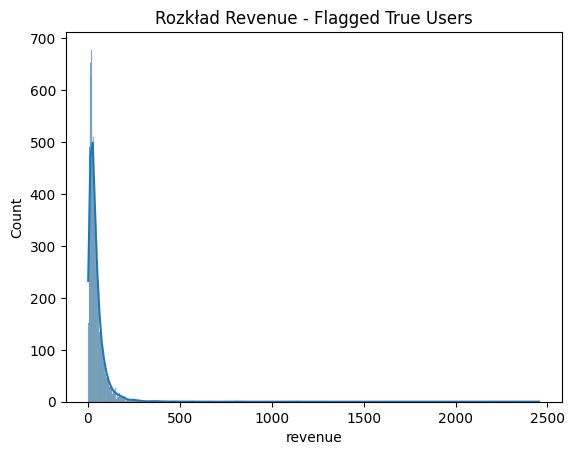

In [7]:
'''Wykres wskazuje na skośność prawostronną. Typowe dla e-commerce'''
sns.histplot(flagged_true_df['revenue'], kde=True)
plt.title('Rozkład Revenue - Flagged True Users')

flagged_true_df["revenue"].quantile([
    0.25,
    0.5,
    0.75,
    0.90,
    0.95,
    0.99
])

true_Q1 = flagged_true_df["revenue"].quantile(0.25)
true_Q3 = flagged_true_df["revenue"].quantile(0.75)

true_iqr = true_Q3 - true_Q1

print(true_iqr)

37.3275


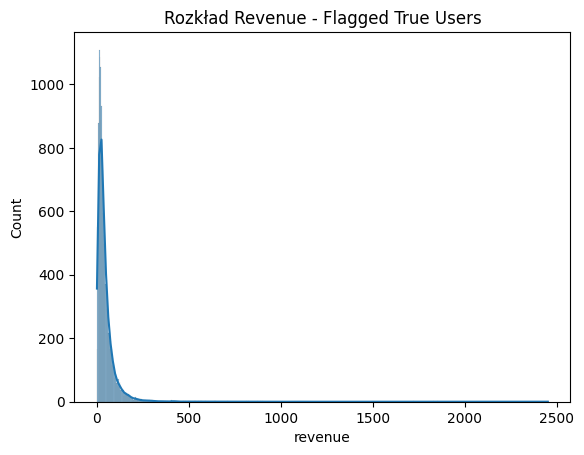

In [8]:
'''Wykres wskazuje na skośność prawostronną. Typowe dla e-commerce'''
sns.histplot(flagged_false_df['revenue'], kde=True)
plt.title('Rozkład Revenue - Flagged True Users')

flagged_false_df["revenue"].quantile([
    0.25,
    0.5,
    0.75,
    0.90,
    0.95,
    0.99
])

false_Q1 = flagged_false_df["revenue"].quantile(0.25)
false_Q3 = flagged_false_df["revenue"].quantile(0.75)

false_iqr = false_Q3  - false_Q1

print(false_iqr)

Wykres wskazuje, że obie grupy generują dodatni profit. Segment True rośnie szybciej od False. Obydwie grupy wskazują duży skok 06.01.2026. Możliwe promocje. Przyczyna do omówienia.

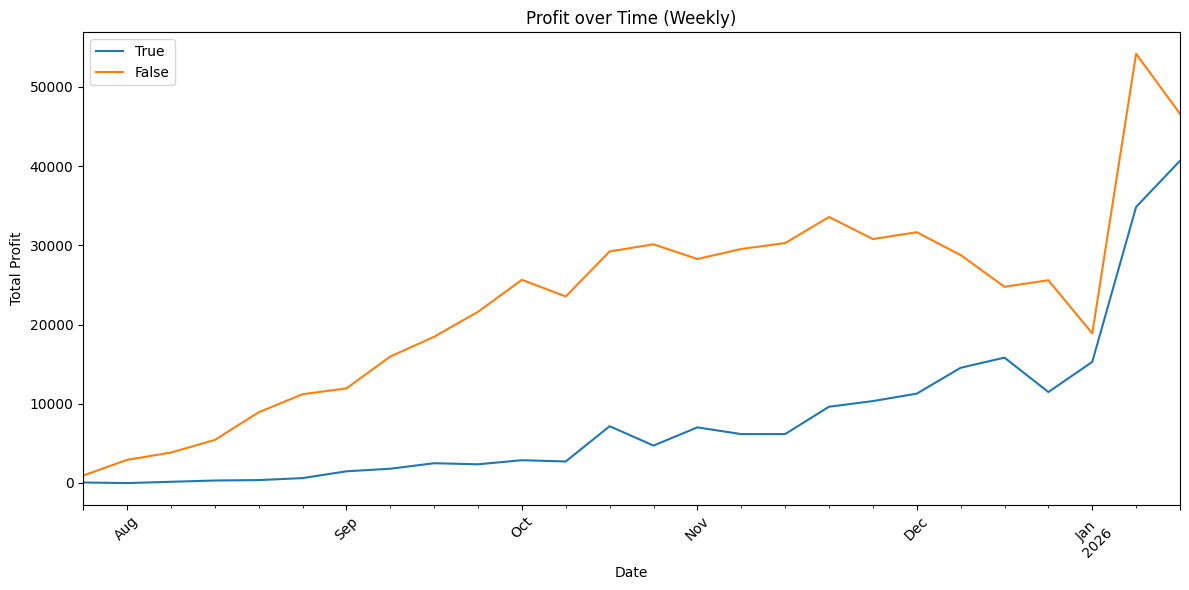

In [9]:
flagged_true_df_prof = flagged_true_df.copy()
flagged_false_df_prof = flagged_false_df.copy()

flagged_true_df_prof['profit'] = (
    flagged_true_df_prof['revenue'] - flagged_true_df_prof['marketing_cost']
)

flagged_true_df_time = (flagged_true_df_prof.groupby(pd.Grouper(key='order_date', freq='W'))['profit'].sum().reset_index())

flagged_false_df_prof['profit'] = flagged_false_df_prof['revenue'] - flagged_false_df_prof['marketing_cost']

flagged_false_df_time = (flagged_false_df_prof.groupby(pd.Grouper(key='order_date', freq='W'))['profit'].sum().reset_index())


true_series = flagged_true_df_time.set_index('order_date')['profit']
false_series = flagged_false_df_time.set_index('order_date')['profit']

df_compare = pd.concat([true_series, false_series], axis=1)
df_compare.columns = ['True', 'False']

df_compare.plot(figsize=(12, 6))

plt.title('Profit over Time (Weekly)')
plt.xlabel('Date')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
'''Licze metryki potrzebne do zadania drugiego'''

# ---------------------------------------------Segment True-----------------------------------------
print(f'Segment oflagowany jako True\n')
# Ilość użytkowników
total_users_true = flagged_true_df['user_id'].nunique()
print(f'Ilość użytkowników:{total_users_true}')

# Ilość zamówień
total_orders_true = flagged_true_df['order_id'].nunique()
print(f'Ilość złożonych zamówień: {total_orders_true}')

# Średnia liczba zamówień (per user)
orders_per_user_true = flagged_true_df.groupby('user_id')['order_id'].count()
avg_true_orders_per_user = orders_per_user_true.mean().round(2)
print(f'Średnia ilość zamówień per user: {avg_true_orders_per_user}')

# Mediana liczby zamówień (per user) ?
median_orders_per_user_true = orders_per_user_true.median()
print(f'Mediana liczby zamówień per user: {median_orders_per_user_true}')

# Suma wszystkich sesji dla segmentu
total_flagged_true_session = flagged_true_df['sessions_before_order'].sum()

# Średnia liczba sesji (per order)
avg_flagged_true_session_per_order = flagged_true_df['sessions_before_order'].mean().round(2)
print(f'Średnia liczba sesji per order: {avg_flagged_true_session_per_order}')

# Mediana liczby sesji (per order)
median_session_before_order_true = flagged_true_df['sessions_before_order'].median().round(2)
print(f'Mediana liczby sesji per order: {median_session_before_order_true}')

# Średnia wartość pojedyńczego zamówienia (AOV)
avg_order_value_true = (total_revenue_true / total_orders_true).round(2)
print(f'Średnia wartość koszyka per order: {avg_order_value_true}')

# Mediana wartości pojedyńczego zamówienia (AOV)
median_aov_true = flagged_true_df['revenue'].median()
print(f'Mediana wartości pojedyńczego zamówienia: {median_aov_true}')

# Średnie LTV obserwowany w segmencie
ltv_per_user_true = flagged_true_df.groupby('user_id')['revenue'].sum()
avg_ltv_true = ltv_per_user_true.mean().round(2)
print(f'Średni przychód z użytkownika: {avg_ltv_true}')

# Mediana typowego użytkownika w segmencie
median_ltv_true = ltv_per_user_true.median()
print(f'Mediana przychodu użytkownika: {median_ltv_true}\n')

# ---------------------------------------------Segment False-----------------------------------------
print(f'Segment oflagowany False\n')
# Ilość zamówień dla oflagowanych użytkowników
total_flagged_false_orders = len(flagged_false_df['order_id'])

# Ilość użytkowników
total_users_false = flagged_false_df['user_id'].nunique()
print(f'Ilość użytkowników: {total_users_false}')

# Ilość zamówień dla oflagowanych użytkowników
total_orders_false = flagged_false_df['order_id'].nunique()
print(f'Ilość złożonych zamówień: {total_orders_false}')

# Średnia liczba zamówień (per user)
avg_false_orders_per_user = round((total_flagged_false_orders/ total_users_false),2)
print(f'Średnia ilość zamówień per user: {avg_false_orders_per_user}')

# Mediana liczby zamówień (per user) ?
orders_per_user_false = flagged_false_df.groupby('user_id')['order_id'].count()
median_orders_per_user_false = orders_per_user_false.median()
print(f'Mediana liczby zamówień per user: {median_orders_per_user_false}')

# Suma wszystkich sesji dla segmentu
total_flagged_false_session = flagged_false_df['sessions_before_order'].sum()

# Średnia liczba sesji (per order)
avg_flagged_false_session_per_order = flagged_false_df['sessions_before_order'].mean().round(2)
print(f'Średnia liczba sesji per order: {avg_flagged_false_session_per_order}')

# Mediana liczby sesji (per order)
median_session_before_order_false = flagged_false_df['sessions_before_order'].median().round(2)
print(f'Mediana liczby sesji per order: {median_session_before_order_false}')

# Średnia wartość pojedyńczego zamówienia (AOV)
avg_order_value_false = (total_revenue_false / total_flagged_false_orders).round(2)
print(f'Średnia wartość koszyka per order: {avg_order_value_false}')

# Mediana wartości pojedyńczego zamówienia (AOV)
median_aov_false = flagged_false_df['revenue'].median()
print(f'Mediana wartości pojedyńczego zamówienia: {median_aov_false}')

# Średnie LTV obserwowany w segmencie
ltv_per_user_false = flagged_false_df.groupby('user_id')['revenue'].sum()
avg_ltv_false = ltv_per_user_false.mean().round(2)
print(f'Średni przychód z użytkownika: {avg_ltv_false}')

# Mediana typowego użytkownika w segmencie
median_ltv_false = ltv_per_user_false.median()
print(f'Mediana przychodu użytkownika: {median_ltv_false}')

Segment oflagowany jako True

Ilość użytkowników:3729
Ilość złożonych zamówień: 8182
Średnia ilość zamówień per user: 2.19
Mediana liczby zamówień per user: 2.0
Średnia liczba sesji per order: 10.29
Mediana liczby sesji per order: 10.0
Średnia wartość koszyka per order: 45.7
Mediana wartości pojedyńczego zamówienia: 30.155
Średni przychód z użytkownika: 100.27
Mediana przychodu użytkownika: 56.06

Segment oflagowany False

Ilość użytkowników: 7343
Ilość złożonych zamówień: 17134
Średnia ilość zamówień per user: 2.33
Mediana liczby zamówień per user: 2.0
Średnia liczba sesji per order: 3.13
Mediana liczby sesji per order: 3.0
Średnia wartość koszyka per order: 46.58
Mediana wartości pojedyńczego zamówienia: 30.01
Średni przychód z użytkownika: 108.69
Mediana przychodu użytkownika: 63.86


### Używam testu statystycznego do sprawdzenia czy różnica w proficie jest statystycznie istotna. 
Test wskazał że istnieje statystyczna różnica w profitach tych dwóch grup. Mediana profitu True jest 43% mniejsza od segmentu False. SUgeruje to, że zaobserwowana różnica może mieć istotne znaczenie z perspektywy biznesowej 

In [ ]:
'''
Używam testu U Mann-Whitney ponieważ dane są skośne

H0: Nie istnieje statystycznie istotna różnica w proficie między segmentami.
H1: Istnieje statystycznie istotna różnica w proficie między segmentami.

alfa = 0.05

P-value < 0.05, dlatego odrzucamy hipotezę zerową.
Istnieją statystyczne dowody na różnicę w rozkładzie profitu pomiędzy segmentami.
'''

from scipy.stats import mannwhitneyu

profit_true = flagged_true_df_prof.loc[flagged_true_df_prof['flagged_segment'] == True, 'profit']
profit_false = flagged_false_df_prof.loc[flagged_false_df_prof['flagged_segment'] == False, 'profit']

stat, p_value = mannwhitneyu(
    profit_true,
    profit_false,
    alternative='two-sided'
)

print(f"Statistic: {stat}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Istnieje statystycznie istotna różnica w proficie między segmentami.")
else:
    print("Brak dowodów na statystycznie istotną różnicę w proficie między segmentami.")

len(profit_true)

median_true = profit_true.median()
median_false = profit_false.median()

# Mediana w grupie True jest o 43% niższa niż mediana w grupie False
diff_pct = (median_true - median_false) / median_false * 100

print(diff_pct)

Statistic: 56235770.5
P-value: 0.000000
Istnieje statystycznie istotna różnica w proficie między segmentami.
-43.61465852304276
-0.4361465852304276


### Tabela retencji użytkowników

In [12]:
'''Aby określić retencje dla swojego snapshotu danych tworzę własną interpretacje first_order_date. Czyli w oflagowanym df jako True określam kiedy było pierwsze zamówienie i licze ilość dni do kolejnego. Dla snapshotu 6 miesięcznego z danymi określam, że tygodniowa retencja bedzie najlepszym rozwiązaniem ze wzgledu na kompromis odnośnie dokładności danych a szumem informacyjnym'''

# ---------------------------------------------Segment True-------------------------------------------------------------------------

# Dzien pierwszego zamowienia per user (True)
first_true_order = flagged_true_df.groupby('user_id')['order_date'].min().reset_index()
first_true_order.rename(columns={'order_date':'first_order_date'}, inplace = True)

retention_true_df = flagged_true_df.merge(first_true_order, on='user_id')


# Licze ilość tygodni od pierwszego zamowienia (True)
retention_true_df['week_since_first'] = (retention_true_df['order_date'] - retention_true_df['first_order_date']).dt.days //7


#Retencja: ilu uzytkownikow pojawilo sie w danym tygodniu po pierwszym zamowienia (True)
weekly_users_count_true = retention_true_df.groupby('week_since_first')['user_id'].nunique()


# Przedstawienie procentowe (True)
weekly_retention_percent_true = (weekly_users_count_true/weekly_users_count_true.iloc[0] * 100).round(2)


# Mediana zamówień w ciągu tygodnia (True)
weekly_orders_user_true = retention_true_df.groupby(['week_since_first','user_id'])['order_id'].count().reset_index()
weekly_orders_per_user_true_median = weekly_orders_user_true.groupby('week_since_first')['order_id'].median()


# ---------------------------------------------Segment False----------------------------------------------------------------------

# Dzien pierwszego zamowienia per user (False)
first_false_order = flagged_false_df.groupby('user_id')['order_date'].min().reset_index()
first_false_order.rename(columns={'order_date':'first_order_date'}, inplace = True)

retention_false_df = flagged_false_df.merge(first_false_order, on='user_id')


# Licze ilość tygodni od pierwszego zamowienia (False)
retention_false_df['week_since_first'] = (retention_false_df['order_date'] - retention_false_df['first_order_date']).dt.days //7


#Retencja: ilu uzytkownikow pojawilo sie w danym tygodniu po pierwszym zamowienia (False)
weekly_users_count_false = retention_false_df.groupby('week_since_first')['user_id'].nunique()


# Przedstawienie procentowe (False)
weekly_retention_percent_false = (weekly_users_count_false/weekly_users_count_false.iloc[0] * 100).round(2)

# Mediana zamówień w ciągu tygodnia (True)
weekly_orders_user_false = retention_false_df.groupby(['week_since_first','user_id'])['order_id'].count().reset_index()
weekly_orders_per_user_false_median = weekly_orders_user_false.groupby('week_since_first')['order_id'].median()

# Porównanie retention userów True i False
retention_table = pd.DataFrame({
    'weekly_users_count_true': weekly_users_count_true,
    'weekly_retention_percent_true': weekly_retention_percent_true,
    'weekly_orders_per_user_true_median': weekly_orders_per_user_true_median,
    'weekly_users_count_false': weekly_users_count_false,
    'weekly_retention_percent_false': weekly_retention_percent_false,
    'weekly_orders_per_user_false_median': weekly_orders_per_user_false_median

})

retention_table.index = [f'Week {i}' for i in retention_table.index]
retention_table = retention_table.fillna(0)
retention_table['weekly_users_count_true'] = retention_table['weekly_users_count_true'].astype(int)
retention_table

,weekly_users_count_true,weekly_retention_percent_true,weekly_orders_per_user_true_median,weekly_users_count_false,weekly_retention_percent_false,weekly_orders_per_user_false_median
Week 0,3729,100.00,1.0,7343,100.00,1.0
Week 1,763,20.46,1.0,1739,23.68,1.0
Week 2,491,13.17,1.0,1249,17.01,1.0
Week 3,337,9.04,1.0,824,11.22,1.0
Week 4,230,6.17,1.0,597,8.13,1.0
Week 5,150,4.02,1.0,436,5.94,1.0
Week 6,85,2.28,1.0,288,3.92,1.0
Week 7,58,1.56,1.0,209,2.85,1.0
Week 8,42,1.13,1.0,151,2.06,1.0
Week 9,22,0.59,1.0,106,1.44,1.0


### Wykres ukazujący retencje użytkowników

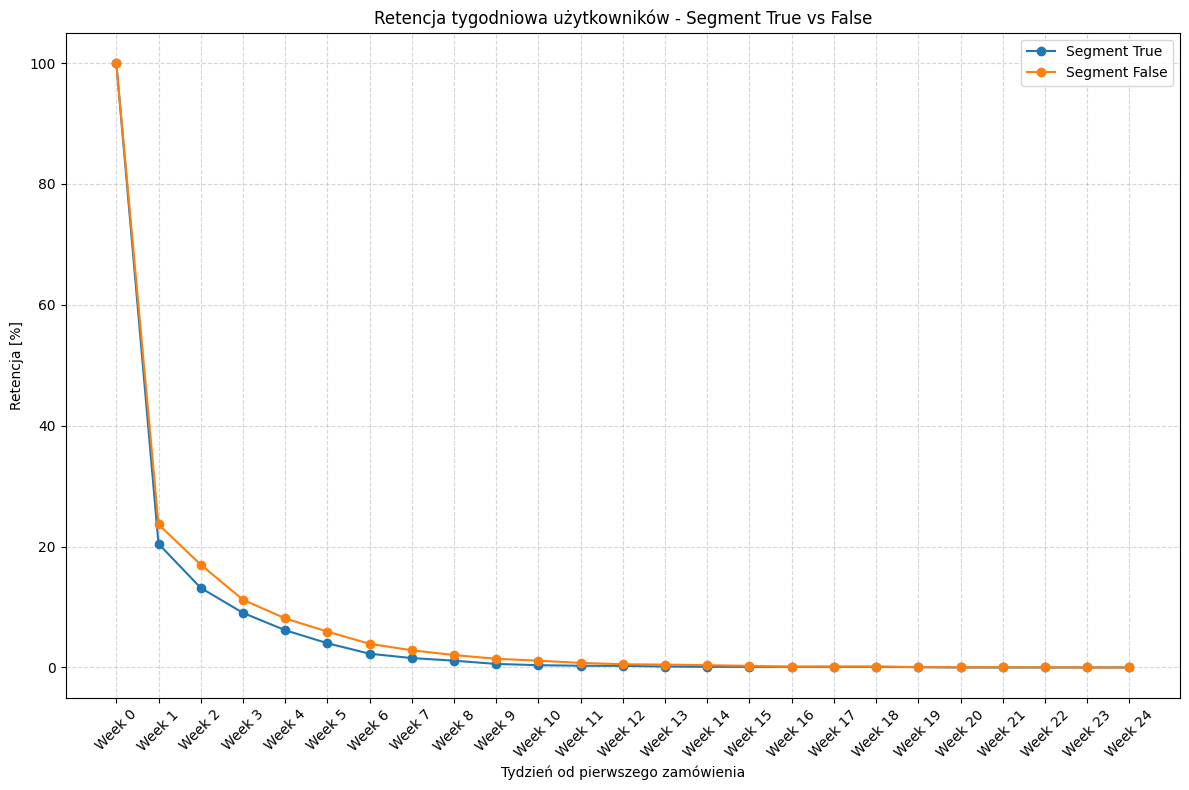

In [13]:
import matplotlib.pyplot as plt

# Dane
weeks = retention_table.index
retention_true = retention_table['weekly_retention_percent_true']
retention_false = retention_table['weekly_retention_percent_false']

# Wykres
plt.figure(figsize=(12,8))
plt.plot(weeks, retention_true, marker='o', label='Segment True')
plt.plot(weeks, retention_false, marker='o', label='Segment False')

# Opis osi
plt.xlabel('Tydzień od pierwszego zamówienia')
plt.ylabel('Retencja [%]')
plt.title('Retencja tygodniowa użytkowników - Segment True vs False')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()


plt.tight_layout()
plt.show()

In [14]:
'''Dodatkowe metryki do sprawdzenia'''

# Czy któryś z krajów przynosi mniejszy profit
flagged_true_df_prof.groupby('country')['profit'].median()

#---------------------------------------------------------Segment True------------------------------------------------

profit_df_true = flagged_true_df.copy()
profit_df_false = flagged_false_df.copy()

# Profit per user True
profit_df_true['profit'] = profit_df_true['revenue'] - profit_df_true['marketing_cost']
profit_per_user_true = profit_df_true.groupby('user_id')['profit'].sum()

# Mediana profitu per user True
median_profit_true = profit_per_user_true.median()

# ROI per user
roi_per_user_true = (profit_per_user_true / profit_df_true.groupby('user_id')['marketing_cost'].sum()) * 100

#---------------------------------------------------------Segment False-----------------------------------------------

# Profit per user False
profit_df_false['profit'] = profit_df_false['revenue'] - profit_df_false['marketing_cost']
profit_per_user_false = profit_df_false.groupby('user_id')['profit'].sum()

# Mediana profitu per user false
median_profit_false = profit_per_user_false.median()

# ROI per user
roi_per_user_false = (profit_per_user_false / profit_df_false.groupby('user_id')['marketing_cost'].sum()) * 100


print(f'Mediana profitu per user (True): {median_profit_true}')
print(f'Mediana ROI per user (True): {roi_df_per_order_true}%')
print(f'Mediana profitu per user (False): {median_profit_false}')
print(f'Mediana ROI per user (False): {roi_df_per_order_false}%')

Mediana profitu per user (True): 21.99
Mediana ROI per user (True): 128.49%
Mediana profitu per user (False): 40.25
Mediana ROI per user (False): 288.19%


### 4. Rekomendacja: Przedstaw konkretną decyzję biznesową: "Stop", "Continue" lub "Pivot" (zmiana strategii). Uzasadnij ją jedną, kluczową metryką.

Rekomendacja: **pivot**. Główna metryka: mediana profitu.

- Segment True nie jest stratny, generuje dodatni profit i ROI jest na wysokim poziomie choć jest mniej efektywny niż segment False
- Nie znaleziono pojedyńczego rynku odpowiedzialnego za problem rentowności
- Analiza wskazuje, że problemem nie jest wartość zamówień. Główną przyczyną niższej rentowności jest wyższy koszt marketingu. Optymalizacja, może zwiększyć rentowność segmentu
- W przypadku wprowadzonych zmian, segment wymaga wzmożonego monitoringu KPI, aby reagować w przypadku spadku ROI

In [15]:
'''Tabela potwierdzająca decyzje'''

comparison = pd.DataFrame({
    'Revenue': [
        flagged_true_df['revenue'].median(),
        flagged_false_df['revenue'].median()
    ],
    'Marketing Cost': [
        flagged_true_df['marketing_cost'].median(),
        flagged_false_df['marketing_cost'].median()
    ],
    'Profit': [
        profit_true.median(),
        profit_false.median()
    ]
}, index=['True', 'False'])

comparison

,Revenue,Marketing Cost,Profit
True,30.155,20.0,10.155
False,30.010,12.0,18.010
